In [1]:
import os
import sys

os.chdir("/Users/karima/Ironhack-challenges/fake-news-nlp-classification")
sys.path.append(os.getcwd())

print(os.getcwd())

/Users/karima/Ironhack-challenges/fake-news-nlp-classification


In [2]:
# %pip install gensim

In [3]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

from src.data_loader import load_data, prepare_features_and_labels, split_data
from src.preprocessing import preprocess_data
from src.feature_extraction import load_glove_model, create_glove_tfidf_weighted_embedding_features
from src.evaluator import evaluate_model, save_confusion_matrix, save_metrics_plot
from src.experiment_tracker import save_experiment_result
from src.model_manager import save_model, save_vectorizer
from src.config import MODELS_DIR

In [4]:
# Class constants
MODEL_ID = 15
MODEL_NAME = "SVM + Word Embeddings"
FEATURES = "TF-IDF Weighted GloVe Word Embeddings"
PREPROCESSING = "Lowercase + HTML removal + stopword removal + lemmatization"
ALGORITHM = "SVM"
NOTES = "SVM model using TF-IDF weighted GloVe document embeddings."
MODEL_PATH = MODELS_DIR / "embeddings_svm.pkl"

In [5]:
# Load the dataset
data = load_data()

In [6]:
# Extract features X and labels y
X, y = prepare_features_and_labels(data)

In [7]:
# Split the data into 80% train and 20% test
X_train, X_test, y_train, y_test = split_data(X, y)

In [8]:
# data cleaning, tokenizationa and lemmatization
X_train_clean = preprocess_data(X_train)
X_test_clean = preprocess_data(X_test)

In [9]:
glove_model = load_glove_model()

In [10]:
# # 5. Create glove tf-idf weighted embeddings features
X_train_embeddings, X_test_embeddings, tfidf_vectorizer = (
    create_glove_tfidf_weighted_embedding_features(
        X_train_clean,
        X_test_clean,
        glove_model
    )
)

In [11]:
# Train LinearSVC model
model = LinearSVC(
    random_state=42,
    max_iter=10000
)

model.fit(X_train_embeddings, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",10000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are s

In [12]:
# evaluate the model
metrics, predictions = evaluate_model(
    model,
    X_test_embeddings,
    y_test
)

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      3989
           1       0.92      0.93      0.93      4000

    accuracy                           0.93      7989
   macro avg       0.93      0.93      0.93      7989
weighted avg       0.93      0.93      0.93      7989



In [13]:
# Save the model and the vectorizer
model_path = save_model(
    model,
    "embeddings_svm.pkl"
)

save_vectorizer(
    tfidf_vectorizer,
    "embeddings_svm_vectorizer.pkl"
)

Model saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/embeddings_svm.pkl
Vectorizer saved to: /Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/embeddings_svm_vectorizer.pkl


'/Users/karima/Ironhack-challenges/fake-news-nlp-classification/models/embeddings_svm_vectorizer.pkl'

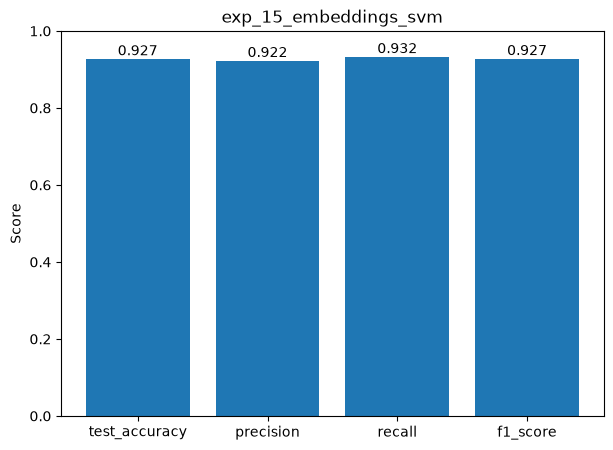

In [14]:
# Save and show metrics plot
metrics_plot_path = save_metrics_plot(
    metrics,
    "exp_15_embeddings_svm"
)

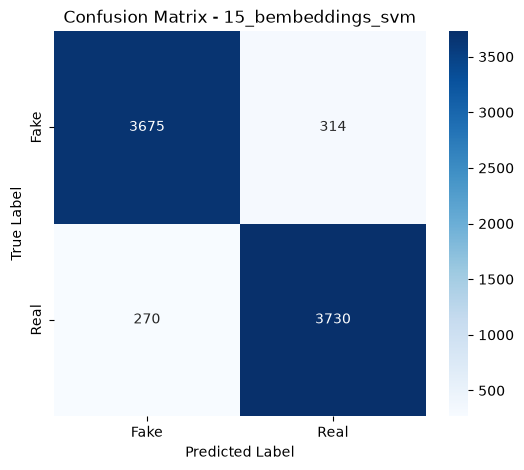

In [15]:
# Save and show confusion matrix
confusion_matrix_path = save_confusion_matrix(
    y_test,
    predictions,
    "15_bembeddings_svm"
)

In [16]:
# Train accuracy
train_predictions = model.predict(X_train_embeddings)
train_accuracy = accuracy_score(y_train, train_predictions)

In [17]:
# Save experiment result
experiment = {
    "model_id": MODEL_ID,
    "model_name": MODEL_NAME,
    "features": FEATURES,
    "preprocessing": PREPROCESSING,
    "algorithm": ALGORITHM,
    "train_accuracy": train_accuracy,
    "test_accuracy": metrics["test_accuracy"],
    "precision": metrics["precision"],
    "recall": metrics["recall"],
    "f1_score": metrics["f1_score"],
    "notes": NOTES,
    "model_path": MODEL_PATH,
}

tracking = save_experiment_result(**experiment)

tracking.tail()

,model_id,model_name,features,preprocessing,algorithm,train_accuracy,test_accuracy,precision,recall,f1_score,notes,model_path
6,exp_13,Logistic Regression + Average GloVe Embeddings,Average GloVe Word Embeddings,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.930992,0.927275,0.923248,0.93225,0.927727,Uses pre-trained GloVe vectors averaged across...,/Users/karima/Ironhack-challenges/fake-news-nl...
7,exp_13,Logistic Regression + Average GloVe Embeddings,Average GloVe Word Embeddings,Lowercase + HTML removal + stopword removal + ...,Logistic Regression,0.933152,0.926399,0.922696,0.93100,0.926829,Uses pre-trained GloVe vectors averaged across...,/Users/karima/Ironhack-challenges/fake-news-nl...
8,exp_14,Random Forest + Word Embeddings,TF-IDF Weighted GloVe Word Embeddings,Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.939417,0.941487,0.93725,0.939364,Random Forest model using TF-IDF weighted GloV...,/Users/karima/Ironhack-challenges/fake-news-nl...
9,exp_14,Random Forest + Word Embeddings,TF-IDF Weighted GloVe Word Embeddings,Lowercase + HTML removal + stopword removal + ...,Random Forest,1.000000,0.939417,0.941487,0.93725,0.939364,Random Forest model using TF-IDF weighted GloV...,/Users/karima/Ironhack-challenges/fake-news-nl...
10,15,SVM + Word Embeddings,TF-IDF Weighted GloVe Word Embeddings,Lowercase + HTML removal + stopword removal + ...,SVM,0.932776,0.926899,0.922354,0.93250,0.927399,SVM model using TF-IDF weighted GloVe document...,/Users/karima/Ironhack-challenges/fake-news-nl...
